# 📊 Exploratory Data Analysis (EDA) - Properti DKI Jakarta

Notebook ini bertujuan untuk mengeksplorasi dataset hasil pembersihan tahap 1 terbaru. 
Kita akan menganalisis hubungan antar variabel, mendeteksi pencilan (outliers), dan mencari faktor-faktor yang paling memengaruhi harga properti di Jakarta.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi visualisasi agar terlihat lebih rapih dan bagus
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', None)

## 1. Load Dataset
Kita akan memuat dataset bersih `dataset_properti_jakarta_master_cleaned.csv` yang telah disiapkan.

In [11]:
df = pd.read_csv('../data/processed/dataset_properti_jakarta_master_cleaned.csv')
print(f"Dimensi data asli: {df.shape[0]} baris dan {df.shape[1]} kolom.")
df.head()

Dimensi data asli: 43735 baris dan 25 kolom.


,ID,URL_ID,Deskripsi,Harga,Kecamatan/Kawasan,Kota,Sertifikat,Kamar_Tidur_Utama,Kamar_Tidur_ART,Kamar_Mandi_Utama,Kamar_Mandi_ART,Garasi_Utama,Carport,Luas_Tanah,Luas_Bangunan,Fasilitas_Siap_Huni,Fasilitas_Bebas_Banjir,Fasilitas_Komplek_Perumahan,Fasilitas_Dekat_Akses_Transportasi,Fasilitas_Dekat_Sekolah,Fasilitas_Dekat_Pusat_Perbelanjaan,Fasilitas_Dekat_Fasilitas_Kesehatan,Fasilitas_Dekat_Tempat_Ibadah,Fasilitas_Dekat_Tempat_Wisata,Fasilitas_Dekat_Landmark
0,1,https://www.rumah123.com/properti/jakarta-sela...,Luxury Living In Pondok Indah,26000000000,Pondok Indah,Jakarta Selatan,SHM,7,0,4,0,2,2,410,500,0,0,0,0,0,0,0,0,0,0
1,2,https://www.rumah123.com/properti/jakarta-pusa...,Rumah Hitung Tanah,19000000000,Tanah Abang,Jakarta Pusat,SHM,2,0,4,1,2,2,700,500,0,0,0,0,0,0,0,0,0,0
2,3,https://www.rumah123.com/properti/jakarta-utar...,Dijual Rumah 3 Lantai Bebas Banjir Hadap Selat...,3000000000,Kelapa Gading,Jakarta Utara,SHM,3,1,3,1,2,0,90,200,1,1,0,1,1,1,1,0,0,0
3,4,https://www.rumah123.com/properti/jakarta-utar...,Dijual Rumah Bagus Siap Huni di Sunter,2300000000,Sunter,Jakarta Utara,SHM,2,0,1,0,1,0,96,120,1,0,0,0,0,0,0,0,0,0
4,5,https://www.rumah123.com/properti/jakarta-bara...,Dijual Rumah Full Furnished Full Renovasi 2 La...,2000000000,Taman Palem,Jakarta Barat,SHM,3,0,2,0,0,0,60,100,0,0,0,0,1,0,0,0,0,0


## 2. Analisis Struktur & Statistik Dasar
Mari cek tipe data dari setiap kolom dan melihat deskripsi statistik dasar untuk variabel numerik.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43735 entries, 0 to 43734
Data columns (total 25 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   ID                                   43735 non-null  int64
 1   URL_ID                               43735 non-null  str  
 2   Deskripsi                            43735 non-null  str  
 3   Harga                                43735 non-null  int64
 4   Kecamatan/Kawasan                    43735 non-null  str  
 5   Kota                                 43735 non-null  str  
 6   Sertifikat                           43735 non-null  str  
 7   Kamar_Tidur_Utama                    43735 non-null  int64
 8   Kamar_Tidur_ART                      43735 non-null  int64
 9   Kamar_Mandi_Utama                    43735 non-null  int64
 10  Kamar_Mandi_ART                      43735 non-null  int64
 11  Garasi_Utama                         43735 non-null  int64
 12  C

In [40]:
# Statistik deskriptif untuk kolom numerik utama
df[['Harga', 'Luas_Tanah', 'Luas_Bangunan', 'Kamar_Tidur_Utama', 'Garasi_Utama', 'Carport']].describe().T

,count,mean,std,min,25%,50%,75%,max
Harga,43735.0,7.846258e+09,8.674911e+09,500000000.0,2.550000e+09,4.500000e+09,9.000000e+09,5.000000e+10
Luas_Tanah,43735.0,2.656764e+02,3.243155e+02,0.0,1.050000e+02,1.760000e+02,3.150000e+02,2.300000e+04
Luas_Bangunan,43735.0,3.040918e+02,5.823765e+02,0.0,1.440000e+02,2.250000e+02,3.900000e+02,7.675200e+04
Kamar_Tidur_Utama,43735.0,4.255791e+00,6.851847e+00,0.0,3.000000e+00,4.000000e+00,5.000000e+00,1.260000e+03
Garasi_Utama,43735.0,1.395290e+00,1.311904e+00,0.0,1.000000e+00,1.000000e+00,2.000000e+00,3.200000e+01
Carport,43735.0,6.950726e-01,1.418665e+00,0.0,0.000000e+00,0.000000e+00,1.000000e+00,3.200000e+01


## 3. Identifikasi Outliers & Strategi Visualisasi
Dalam analisis data properti, terdapat pencilan ekstrem (outliers) yang disebabkan oleh:
1. **Kesalahan input saat scraping** (misalnya luas bangunan tertulis >70.000 m²).
2. **Properti Ultra-Mewah** (harga mencapai Rp 50 Miliar atau luas tanah ribuan meter persegi) yang jumlahnya sangat sedikit namun mendominasi skala grafik.

Untuk membuat visualisasi grafik yang **jelas, terbaca, dan tidak terkompresi di sudut**, kita akan memfilter visualisasi untuk **Pasar Normal (Normal Market)** dengan batasan berikut (mencakup >95% data):
- **Harga** <= Rp 25 Miliar
- **Luas Tanah** <= 1.000 m²
- **Luas Bangunan** <= 1.000 m²

*Catatan: Filter ini hanya digunakan untuk tujuan visualisasi agar pola data terlihat jelas, sedangkan untuk pemodelan machine learning nanti kita bisa menggunakan teknik pembersihan outlier yang lebih ketat.*

In [4]:
# Membuat subset data khusus visualisasi pasar normal
df_viz = df[(df['Harga'] <= 25_000_000_000) & 
            (df['Luas_Tanah'] <= 1000) & 
            (df['Luas_Bangunan'] <= 1000)]

df_viz = df_viz[df_viz['Luas_Tanah'] > 0]  # Pastikan hanya luas tanah positif yang dianalisis
df_viz = df_viz[df_viz['Luas_Bangunan'] > 0]  # Pastikan hanya luas bangunan positif yang dianalisis

print(f"Jumlah data setelah filter visualisasi: {df_viz.shape[0]} baris ({df_viz.shape[0]/len(df)*100:.2f}% dari data asli).")

Jumlah data setelah filter visualisasi: 40353 baris (92.27% dari data asli).


## 4. Distribusi Harga Properti
Mari kita visualisasikan distribusi harga properti pada pasar normal.

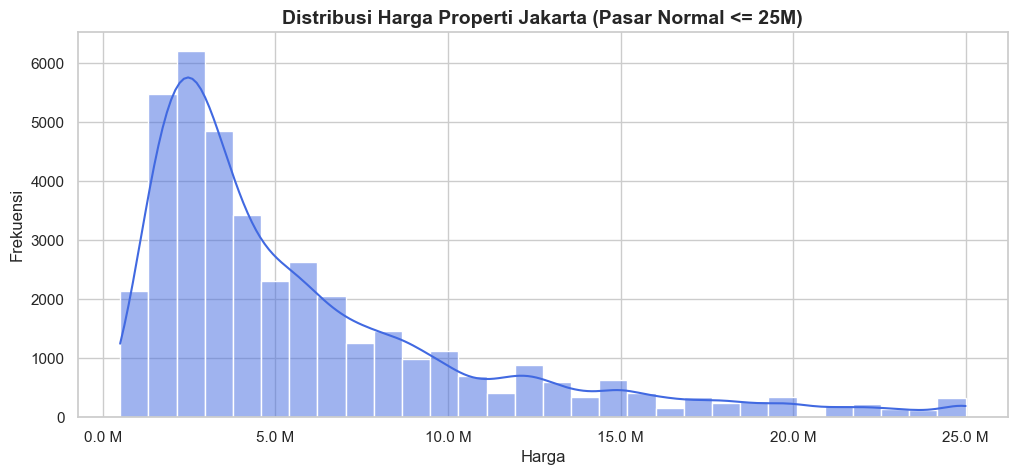

In [5]:
# Distribusi Harga Properti
plt.figure(figsize=(12, 5))
sns.histplot(df_viz['Harga'], bins=30, kde=True, color='royalblue')
plt.title('Distribusi Harga Properti Jakarta (Pasar Normal <= 25M)', fontsize=14, fontweight='bold')
plt.xlabel('Harga', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)

# Format sumbu X agar menampilkan label Miliar (M) daripada angka nol yang panjang
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e9:.1f} M'))
plt.show()

## 5. Hubungan Dimensi Fisik (Luas) Terhadap Harga
Faktor fisik seperti luas lahan biasanya merupakan penentu harga paling kuat. Dengan menghilangkan outlier ekstrem, korelasi positifnya akan terlihat sangat jelas.

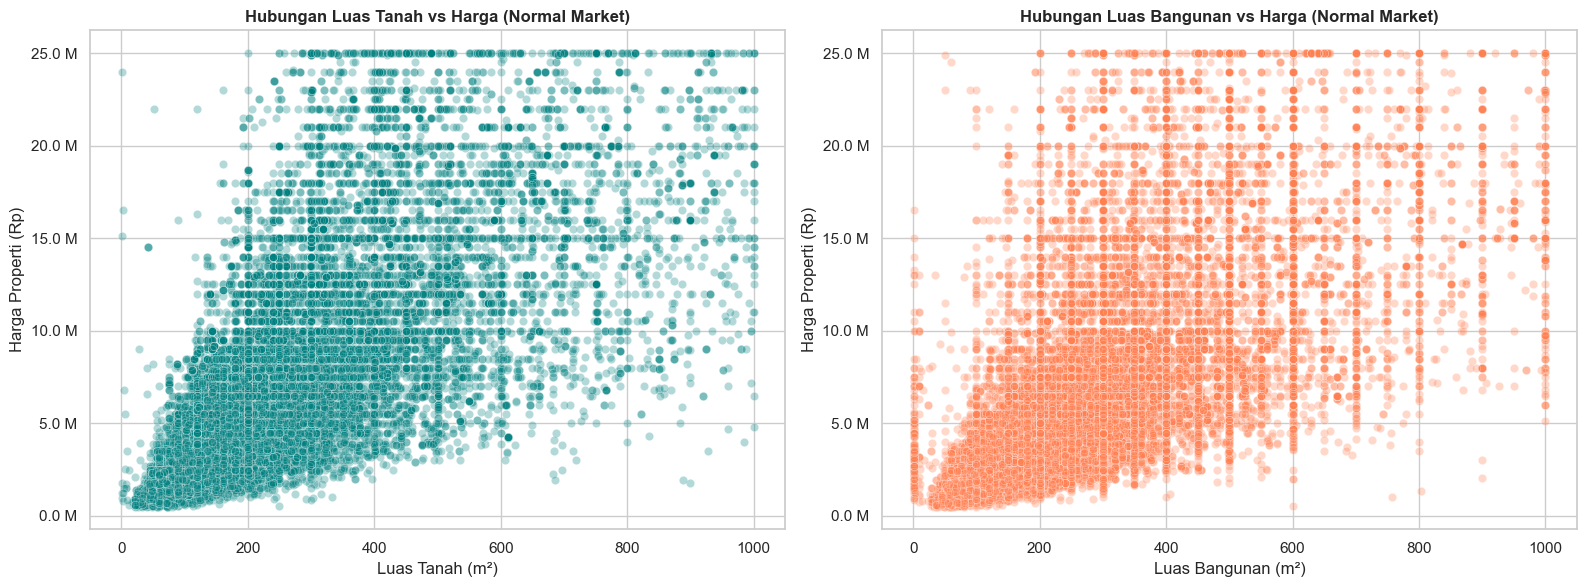

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Luas Tanah vs Harga
sns.scatterplot(data=df_viz, x='Luas_Tanah', y='Harga', alpha=0.3, ax=axes[0], color='teal')
axes[0].set_title('Hubungan Luas Tanah vs Harga (Normal Market)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Luas Tanah (m²)')
axes[0].set_ylabel('Harga Properti (Rp)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e9:.1f} M'))

# Luas Bangunan vs Harga
sns.scatterplot(data=df_viz, x='Luas_Bangunan', y='Harga', alpha=0.3, ax=axes[1], color='coral')
axes[1].set_title('Hubungan Luas Bangunan vs Harga (Normal Market)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Luas Bangunan (m²)')
axes[1].set_ylabel('Harga Properti (Rp)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e9:.1f} M'))

plt.tight_layout()
plt.show()

## 6. Analisis Harga Berdasarkan Wilayah Administratif
Mari kita lihat median harga properti di setiap Kota Administratif Jakarta pada pasar normal.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9460\1107393061.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=harga_wilayah, x='Harga', y='Kota', palette='viridis')


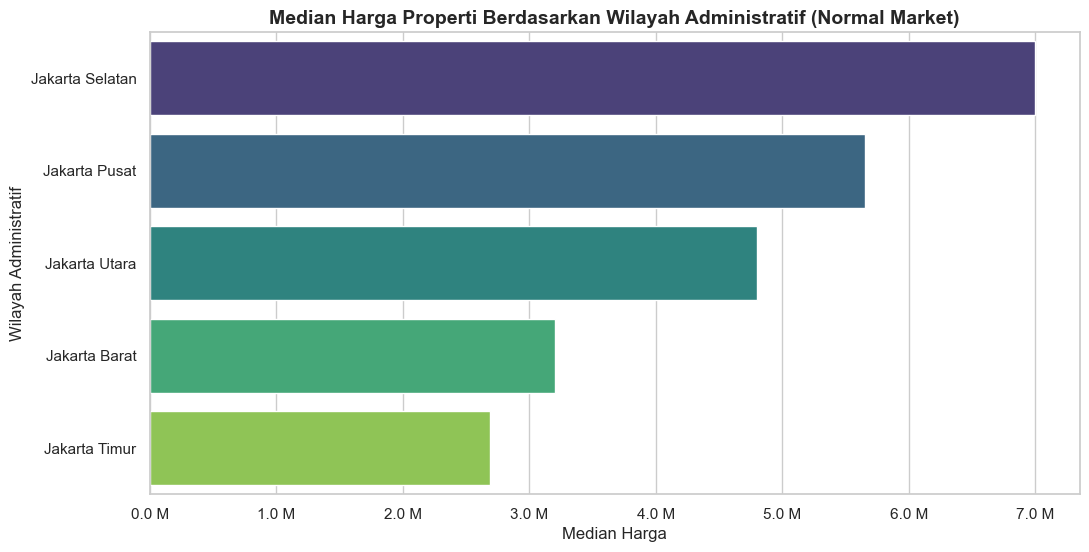

In [7]:
# Kelompokkan berdasarkan kota administratif dan hitung harga mediannya
harga_wilayah = df_viz.groupby('Kota')['Harga'].median().reset_index()\
                      .sort_values(by='Harga', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=harga_wilayah, x='Harga', y='Kota', palette='viridis')
plt.title('Median Harga Properti Berdasarkan Wilayah Administratif (Normal Market)', fontsize=14, fontweight='bold')
plt.xlabel('Median Harga', fontsize=12)
plt.ylabel('Wilayah Administratif', fontsize=12)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e9:.1f} M'))
plt.show()

## 7. Dampak Fitur Biner (Siap Huni dan Perumahan) Terhadap Harga
Mari kita buktikan secara data apakah status bebas banjir atau status lelang berpengaruh nyata pada harga jual rumah di pasar normal.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9460\2125774001.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_viz, x='Fasilitas_Siap_Huni', y='Harga', ax=axes[0], showfliers=False, palette='pastel')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9460\2125774001.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Tidak Siap Huni (0)', 'Siap Huni (1)'])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9460\2125774001.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_viz, x='Fasilitas_Komplek_Perumahan', y='Harga', ax=axes[1], showfliers=False, palette='muted')
C:\User

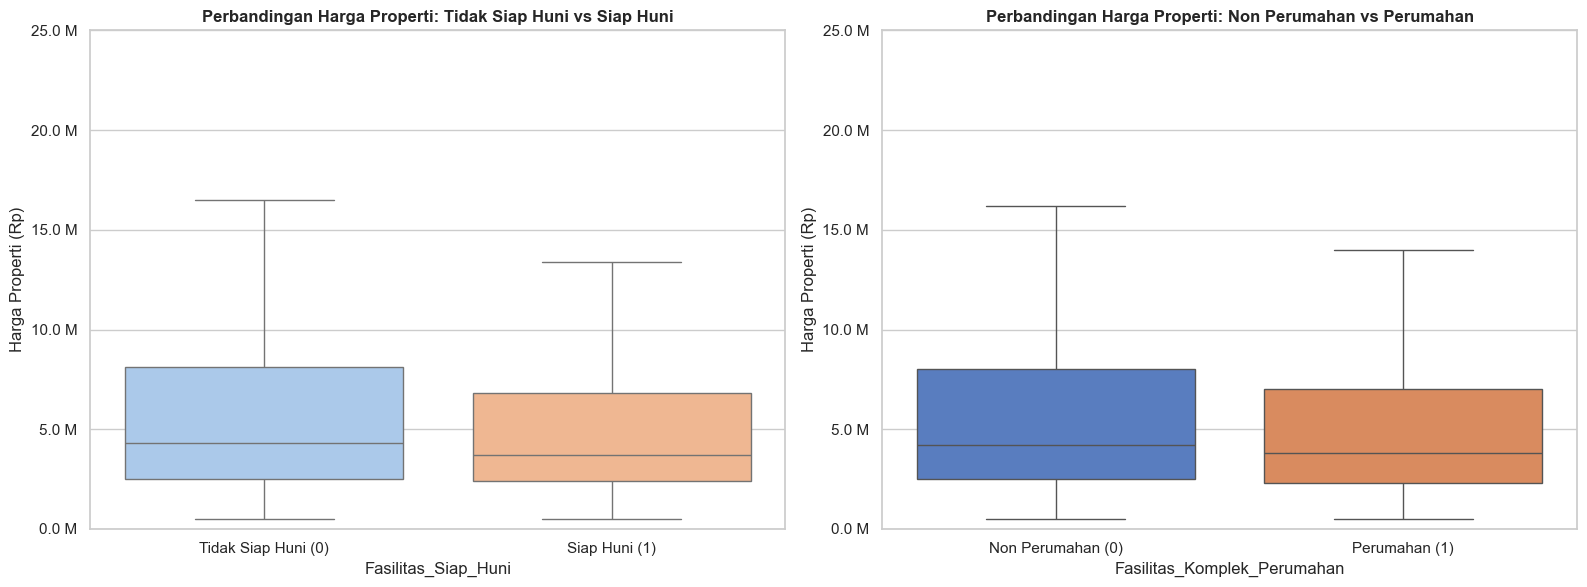

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Perbandingan Harga: Tidak Siap Huni vs Siap Huni
sns.boxplot(data=df_viz, x='Fasilitas_Siap_Huni', y='Harga', ax=axes[0], showfliers=False, palette='pastel')
axes[0].set_title('Perbandingan Harga Properti: Tidak Siap Huni vs Siap Huni', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['Tidak Siap Huni (0)', 'Siap Huni (1)'])
axes[0].set_ylabel('Harga Properti (Rp)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e9:.1f} M')) 
axes[0].set_ylim(0, 25_000_000_000) # ZOOM sumbu Y ke 10 Miliar

# Perbandingan Harga: Non Perumahan vs Perumahan
sns.boxplot(data=df_viz, x='Fasilitas_Komplek_Perumahan', y='Harga', ax=axes[1], showfliers=False, palette='muted')
axes[1].set_title('Perbandingan Harga Properti: Non Perumahan vs Perumahan', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(['Non Perumahan (0)', 'Perumahan (1)'])
axes[1].set_ylabel('Harga Properti (Rp)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e9:.1f} M'))
axes[1].set_ylim(0, 25_000_000_000) # ZOOM sumbu Y ke 30 Miliar

plt.tight_layout()
plt.show()

## 8. Matriks Korelasi Numerik
Melihat korelasi linear antara variabel fisik properti dan harga.

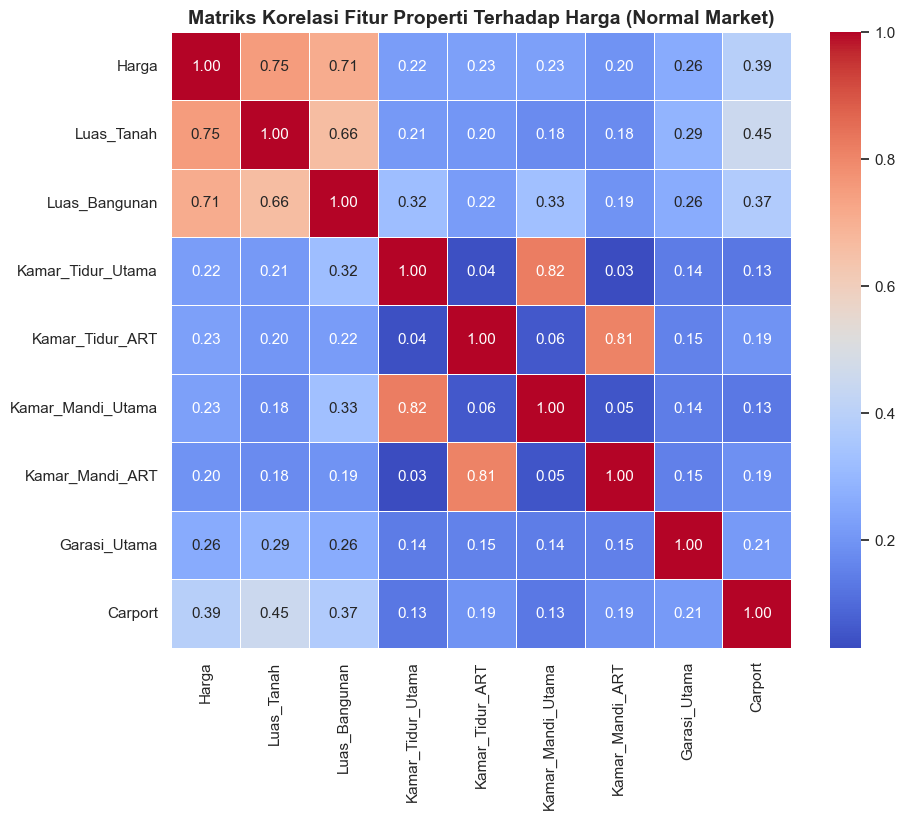

In [ ]:
kolom_numerik = [
    'Harga', 'Luas_Tanah', 'Luas_Bangunan', 
    'Kamar_Tidur_Utama', 'Kamar_Tidur_ART', 
    'Kamar_Mandi_Utama', 'Kamar_Mandi_ART',
    'Garasi_Utama', 'Carport'
]

matriks_korelasi = df_viz[kolom_numerik].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriks_korelasi, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi Fitur Utama Properti Terhadap Harga (Normal Market)', fontsize=14, fontweight='bold')
plt.show()

### Kesimpulan Akhir EDA:
1. **Hubungan Luas vs Harga**: Setelah membuang outliers ekstrem, Luas Tanah dan Luas Bangunan terbukti memiliki hubungan positif linier yang kuat terhadap Harga properti.
2. **Pola Wilayah**: Jakarta Selatan menduduki median harga tertinggi, disusul oleh Jakarta Pusat, sedangkan Jakarta Timur memiliki median harga yang paling terjangkau.
3. **Dampak Banjir**: Rumah yang berstatus *Bebas Banjir* cenderung memiliki median harga yang lebih tinggi dibandingkan rumah di kawasan rawan banjir.
4. **Dampak Lelang**: Rumah dengan status *Lelang* memiliki median harga yang lebih rendah. Ini membuktikan bahwa properti lelang bank dijual di bawah harga wajar pasar (distressed asset).
5. **Format y-axis**: Penskalaan dalam satuan Miliar (M) sangat membantu pembacaan sebaran harga daripada menggunakan notasi ilmiah (`1e10`).